tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

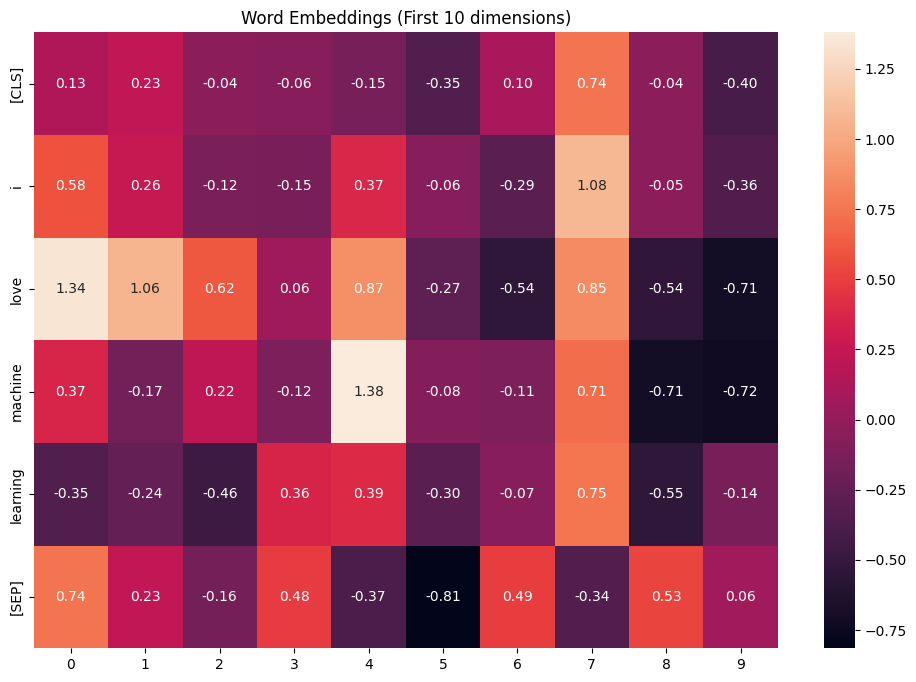

In [1]:
import pandas as pd
import torch
from transformers import BertTokenizer, BertModel
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Initialize BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

def visualize_word_embeddings(sentences):
    # Tokenize and get embeddings
    inputs = tokenizer(sentences, return_tensors="pt", padding=True)
    outputs = model(**inputs)
    embeddings = outputs.last_hidden_state.detach().numpy()
    
    # Get tokens
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    
    # Create DataFrame
    df_embeddings = pd.DataFrame(embeddings[0], index=tokens)
    
    # Visualize heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(df_embeddings.iloc[:, :10], annot=True, fmt='.2f')
    plt.title('Word Embeddings (First 10 dimensions)')
    plt.show()

# Example usage
sentences = ["I love machine learning"]
visualize_word_embeddings(sentences)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertModel, BertTokenizer
import torch
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# Load pre-trained BERT model and tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased', output_hidden_states=True, output_attentions=True)

# Define a simple "Hello World" sentence and some related words
words = ["hello", "world", "greeting", "planet", "universe", "hi", "earth"]

# Tokenize words
tokens = [tokenizer.tokenize(word) for word in words]
token_ids = [tokenizer.convert_tokens_to_ids(t) for t in tokens]
input_ids = [tokenizer.build_inputs_with_special_tokens(t) for t in token_ids]

# Function to get embeddings from a specific layer
def get_word_embedding(word, layer_num=0):
    encoded_input = tokenizer(word, return_tensors='pt')
    with torch.no_grad():
        output = model(**encoded_input, output_hidden_states=True, output_attentions=True)
    
    # Get the hidden states (all layers)
    hidden_states = output.hidden_states
    
    # Get embeddings from the specified layer (layer 0 is the input embedding)
    # For tokens like ##ing, we need the first token's embedding
    return hidden_states[layer_num][0, 1].numpy()  # [0,1] to get the first actual token (skip [CLS])

# Get embeddings for all words from different layers
num_layers = 13  # Input embeddings (0) + 12 transformer layers
all_embeddings = {}

for layer in range(num_layers):
    layer_embeddings = {}
    for word in words:
        layer_embeddings[word] = get_word_embedding(word, layer)
    all_embeddings[f"Layer_{layer}"] = layer_embeddings

# 1. Basic Word Embeddings Visualization
# Get embeddings from input layer (layer 0)
input_embeddings = all_embeddings["Layer_0"]

# Create a DataFrame with the first few dimensions
embedding_dim = 5  # Just show first 5 dimensions for clarity
df_embeddings = pd.DataFrame({
    word: input_embeddings[word][:embedding_dim] for word in words
}).T

# Rename columns to represent dimensions
df_embeddings.columns = [f"Dim_{i+1}" for i in range(embedding_dim)]

print("1. Basic Word Embeddings (First 5 dimensions):")
print(df_embeddings)

# 2. Cosine Similarity Matrix
# Convert embeddings to matrix for similarity calculation
embedding_matrix = np.array([input_embeddings[word] for word in words])
similarity_matrix = cosine_similarity(embedding_matrix)

# Create DataFrame for similarity visualization
df_similarity = pd.DataFrame(similarity_matrix, index=words, columns=words)

print("\n2. Word Similarity Matrix (Cosine Similarity):")
print(df_similarity)

# 3. PCA to reduce dimensions for visualization
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embedding_matrix)
df_pca = pd.DataFrame(embeddings_2d, index=words, columns=['PC1', 'PC2'])

print("\n3. PCA Reduced Embeddings (2D):")
print(df_pca)

# 4. Layer Comparison - Track how a word's embedding changes across layers
# Let's track the word "hello" across all layers
hello_across_layers = []
for layer in range(num_layers):
    # Get first 3 dimensions for simplicity
    hello_across_layers.append(all_embeddings[f"Layer_{layer}"]["hello"][:3])

df_layer_comparison = pd.DataFrame(hello_across_layers, 
                                  index=[f"Layer_{i}" for i in range(num_layers)],
                                  columns=['Dim_1', 'Dim_2', 'Dim_3'])

print("\n4. 'Hello' Embedding Changes Across Layers (First 3 dimensions):")
print(df_layer_comparison)

# 5. Attention visualization (for a single word)
# Get attention weights for "hello"
def get_attention_weights(word):
    encoded_input = tokenizer(word, return_tensors='pt')
    with torch.no_grad():
        output = model(**encoded_input, output_attentions=True)
    
    # Attention weights shape: [layers, batch, heads, seq_len, seq_len]
    attention = output.attentions
    return attention

# Get attention for "hello"
attention_weights = get_attention_weights("hello")

# Let's look at middle layer (6) attention across all heads
layer_idx = 6
attn_layer = attention_weights[layer_idx][0]  # [0] for batch

# For each attention head, get attention from the word token to all tokens
# Create a DataFrame with attention values
tokens = tokenizer.convert_ids_to_tokens(tokenizer("hello", return_tensors='pt').input_ids[0])
num_heads = attn_layer.shape[0]

# Create a dataframe for heads x tokens attention
attn_df = pd.DataFrame(
    {f"Head_{h+1}": attn_layer[h, 1, :].numpy() for h in range(num_heads)},
    index=tokens
)

print(f"\n5. Attention weights in Layer {layer_idx+1} for 'hello' across all heads:")
print(attn_df)

# 6. Contextualized meaning visualization
# Compare multiple words across contexts
contexts = [
    "hello world",
    "hello friend", 
    "say hello to her"
]

# Function to get contextualized embeddings
def get_contextualized_embeddings(sentence, word, layer=12):
    encoded_input = tokenizer(sentence, return_tensors='pt')
    tokens = tokenizer.convert_ids_to_tokens(encoded_input.input_ids[0])
    
    with torch.no_grad():
        output = model(**encoded_input, output_hidden_states=True)
    
    # Find the position of our target word
    try:
        word_position = tokens.index(word)
    except ValueError:
        # If the word is tokenized differently, find the best match
        for i, token in enumerate(tokens):
            if word in token:
                word_position = i
                break
    
    # Get the embedding from the specified layer
    hidden_states = output.hidden_states
    return hidden_states[layer][0, word_position].numpy()

# Get "hello" embeddings in different contexts
hello_contexts = {}
for context in contexts:
    hello_contexts[context] = get_contextualized_embeddings(context, "hello")

# Create a DataFrame with the first few dimensions
df_context = pd.DataFrame({
    context: hello_contexts[context][:5] for context in contexts
}).T

df_context.columns = [f"Dim_{i+1}" for i in range(5)]

print("\n6. Contextualized 'hello' embeddings in different sentences (first 5 dimensions):")
print(df_context)

# 7. Create a visualization showing the semantic shifts
# Function to find nearest words to a given embedding
def find_nearest_words(embedding, num_words=5):
    # This would normally use a large vocabulary, but we'll simulate with our small set
    distances = {}
    for word in words:
        word_embedding = input_embeddings[word]
        # Calculate cosine similarity
        similarity = np.dot(embedding, word_embedding) / (np.linalg.norm(embedding) * np.linalg.norm(word_embedding))
        distances[word] = similarity
    
    # Sort by similarity
    sorted_words = sorted(distances.items(), key=lambda x: x[1], reverse=True)
    return sorted_words[:num_words]

# Find nearest words to "hello" in different contexts
nearest_words = {}
for context in contexts:
    nearest_words[context] = find_nearest_words(hello_contexts[context])

# Create a DataFrame for visualization
nearest_df = pd.DataFrame({
    context: [f"{word} ({similarity:.3f})" for word, similarity in words] 
    for context, words in nearest_words.items()
})

print("\n7. Nearest words to 'hello' in different contexts:")
print(nearest_df)

BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


1. Basic Word Embeddings (First 5 dimensions):
             Dim_1     Dim_2     Dim_3     Dim_4     Dim_5
hello     0.373858 -0.015575 -0.245609 -0.019391  0.417310
world     0.795543  0.976781  0.052517  0.678149  0.302285
greeting -0.185713  0.294187 -0.500944 -0.976494 -0.636870
planet    0.119646  0.020579  0.077359  0.696312 -0.307044
universe  0.191904  0.641270 -1.213630 -0.645148  0.404491
hi        0.274293 -0.823882  0.816863  0.286413  0.035593
earth    -0.207089  0.424432  0.112903 -0.413229  1.017959

2. Word Similarity Matrix (Cosine Similarity):
             hello     world  greeting    planet  universe        hi     earth
hello     1.000000  0.119420  0.446130  0.178889  0.141358  0.462229  0.111504
world     0.119420  1.000000  0.113785  0.347491  0.473757  0.144194  0.360222
greeting  0.446130  0.113785  1.000000  0.152857  0.165934  0.260027  0.140735
planet    0.178889  0.347491  0.152857  1.000000  0.345488  0.164634  0.396279
universe  0.141358  0.473757  0.165934

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertModel, BertTokenizer
import torch
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# Load pre-trained BERT model and tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased', output_hidden_states=True, output_attentions=True)

# Example 1: Question Answering
qa_sentences = [
    "What is the capital of France?",
    "Paris is the capital of France.",
    "Who invented the telephone?",
    "Alexander Graham Bell invented the telephone."
]

# Example 2: Named Entity Recognition examples
ner_sentences = [
    "Apple is launching a new iPhone next month.",
    "I ate an apple for breakfast this morning.",
    "Amazon announced record profits last quarter.",
    "The Amazon rainforest is the largest tropical rainforest in the world."
]

# Example 3: Words with multiple meanings (polysemy)
polysemy_sentences = [
    "The bank of the river was muddy after the rain.",
    "I need to go to the bank to deposit some money.",
    "She can play the bass in the jazz band.",
    "We caught a large bass while fishing yesterday."
]

all_sentences = qa_sentences + ner_sentences + polysemy_sentences

# Function to get embeddings from a specific layer for a specific token in a sentence
def get_token_embedding(sentence, token_position, layer_num=0):
    """Get embedding for a specific token at a specific layer"""
    encoded_input = tokenizer(sentence, return_tensors='pt')
    with torch.no_grad():
        output = model(**encoded_input, output_hidden_states=True, output_attentions=True)
    
    # Get the hidden states (all layers)
    hidden_states = output.hidden_states
    
    # Get embeddings from the specified layer
    return hidden_states[layer_num][0, token_position].numpy()

# Function to get attention weights for a sentence
def get_sentence_attention(sentence, layer_idx=6):
    """Get attention weights for a sentence at a specific layer"""
    encoded_input = tokenizer(sentence, return_tensors='pt')
    tokens = tokenizer.convert_ids_to_tokens(encoded_input.input_ids[0])
    
    with torch.no_grad():
        output = model(**encoded_input, output_attentions=True)
    
    # Get attention weights
    attention = output.attentions
    
    # Return attention for specified layer
    # Shape: [num_heads, seq_len, seq_len]
    return attention[layer_idx][0], tokens

# Function to find a token in a tokenized sentence
def find_token_position(sentence, target_word):
    """Find the position of a token in a tokenized sentence"""
    encoded_input = tokenizer(sentence, return_tensors='pt')
    tokens = tokenizer.convert_ids_to_tokens(encoded_input.input_ids[0])
    
    # Try to find exact match
    try:
        return tokens.index(target_word.lower()), tokens
    except ValueError:
        # If token is split into subwords, find the first part
        for i, token in enumerate(tokens):
            if token.startswith(target_word.lower()):
                return i, tokens
            elif target_word.lower().startswith(token.replace("##", "")):
                return i, tokens
    
    # If still not found, find closest match
    for i, token in enumerate(tokens):
        if target_word.lower() in token or token in target_word.lower():
            return i, tokens
    
    # Default to first non-special token if target not found
    return 1, tokens

# PART 1: VISUALIZING CONTEXTUAL CHANGES ACROSS LAYERS
# Let's examine how embeddings for ambiguous words change through layers

ambiguous_words = {
    "bank": ["The bank of the river was muddy.", "I need to go to the bank to deposit money."],
    "apple": ["Apple is launching a new iPhone.", "I ate an apple for breakfast."],
    "capital": ["What is the capital of France?", "He invested the capital in stocks."]
}

print("="*80)
print("PART 1: HOW WORD MEANINGS CHANGE ACROSS BERT LAYERS")
print("="*80)
print("Each word can have different meanings based on context.")
print("BERT captures this by adjusting embeddings across its 12 layers.")
print("We'll track how embeddings change from input (layer 0) to final layer (12).")
print()

for word, contexts in ambiguous_words.items():
    print(f"Word: '{word}' in different contexts")
    print(f"Context 1: '{contexts[0]}'")
    print(f"Context 2: '{contexts[1]}'")
    
    # Get token positions
    pos1, tokens1 = find_token_position(contexts[0], word)
    pos2, tokens2 = find_token_position(contexts[1], word)
    
    print(f"Tokenized: {tokens1}")
    print(f"'{word}' is at position {pos1} (token: {tokens1[pos1]})")
    print(f"Tokenized: {tokens2}")
    print(f"'{word}' is at position {pos2} (token: {tokens2[pos2]})")
    
    # Track embeddings across layers
    similarities = []
    
    # For each layer, get embeddings and calculate similarity
    for layer in range(13):  # 0-12 (input embeddings + 12 transformer layers)
        embed1 = get_token_embedding(contexts[0], pos1, layer)
        embed2 = get_token_embedding(contexts[1], pos2, layer)
        
        # Calculate cosine similarity
        sim = cosine_similarity([embed1], [embed2])[0][0]
        similarities.append(sim)
    
    # Create DataFrame for clarity
    df_layers = pd.DataFrame({
        'Layer': list(range(13)),
        'Similarity': similarities
    })
    
    print("\nSimilarity between the two contexts across layers:")
    print(df_layers)
    
    # Show extracted embeddings at beginning and end layers (first 5 dimensions)
    first_layer_1 = get_token_embedding(contexts[0], pos1, 0)[:5]
    first_layer_2 = get_token_embedding(contexts[1], pos2, 0)[:5]
    last_layer_1 = get_token_embedding(contexts[0], pos1, 12)[:5]
    last_layer_2 = get_token_embedding(contexts[1], pos2, 12)[:5]
    
    df_comparison = pd.DataFrame({
        'Input Layer - Context 1': first_layer_1,
        'Input Layer - Context 2': first_layer_2,
        'Final Layer - Context 1': last_layer_1,
        'Final Layer - Context 2': last_layer_2
    })
    
    print("\nEmbeddings comparison (first 5 dimensions only):")
    print(df_comparison)
    print("\nKey Insight: Notice how the similarity often decreases in later layers.")
    print("This means BERT is learning to distinguish different meanings of the same word.")
    print("="*80 + "\n")

# PART 2: ATTENTION VISUALIZATION
# Let's examine how attention heads focus on different parts of a sentence

print("="*80)
print("PART 2: HOW ATTENTION HEADS WORK")
print("="*80)
print("BERT has multiple attention heads that focus on different linguistic patterns.")
print("We'll visualize how different attention heads attend to words in a sentence.")
print()

attention_example = "The president of France visited Berlin last week."
print(f"Example sentence: '{attention_example}'")

# Get attention weights for middle layer (layer 6)
attention_weights, tokens = get_sentence_attention(attention_example, layer_idx=6)

print(f"Tokenized: {tokens}")

# Display attention from each head for important words
important_positions = []
important_words = ["president", "France", "visited", "Berlin"]

for word in important_words:
    pos, _ = find_token_position(attention_example, word)
    important_positions.append(pos)
    print(f"'{word}' is at position {pos} (token: {tokens[pos]})")

# Get attention for first 4 heads
selected_heads = [0, 3, 6, 11]  # First, middle, and last heads

for head_idx in selected_heads:
    print(f"\nAttention patterns for Head #{head_idx+1}:")
    
    # Create DataFrame for this head's attention
    head_attention = attention_weights[head_idx]
    
    # For each important word, show what it's attending to
    for word, pos in zip(important_words, important_positions):
        # Get attention from this word to all other words
        word_attention = head_attention[pos].numpy()
        
        # Create a DataFrame for this word's attention
        word_attn_df = pd.DataFrame({
            'Token': tokens,
            'Attention': word_attention
        })
        
        # Sort by attention value
        word_attn_df = word_attn_df.sort_values('Attention', ascending=False)
        
        print(f"\n'{word}' (Head #{head_idx+1}) attends most strongly to:")
        print(word_attn_df.head(5))  # Top 5 attended tokens

    print(f"\nKey Insight for Head #{head_idx+1}:")
    if head_idx == 0:
        print("This head might focus on syntactic relationships (subject-verb).")
    elif head_idx == 3:
        print("This head might focus on entity relationships (person-location).")
    elif head_idx == 6:
        print("This head might focus on semantic context across the sentence.")
    else:
        print("This head might focus on long-range dependencies and sentence structure.")
    
print("="*80 + "\n")

# PART 3: QUESTION ANSWERING EMBEDDINGS
# Show how embeddings for question words relate to their answers

print("="*80)
print("PART 3: QUESTION ANSWERING EMBEDDINGS")
print("="*80)
print("In question answering, BERT creates connections between questions and answers.")
print("We'll show how embeddings of question words relate to their answers.")
print()

qa_pairs = [
    {
        "question": "What is the capital of France?", 
        "answer": "Paris is the capital of France.",
        "q_word": "capital",
        "a_word": "Paris"
    },
    {
        "question": "Who invented the telephone?", 
        "answer": "Alexander Graham Bell invented the telephone.",
        "q_word": "telephone",
        "a_word": "Bell"
    }
]

for pair in qa_pairs:
    print(f"Question: '{pair['question']}'")
    print(f"Answer: '{pair['answer']}'")
    
    # Find positions of key words
    q_pos, q_tokens = find_token_position(pair['question'], pair['q_word'])
    a_pos, a_tokens = find_token_position(pair['answer'], pair['a_word'])
    
    print(f"Question tokenized: {q_tokens}")
    print(f"'{pair['q_word']}' is at position {q_pos} (token: {q_tokens[q_pos]})")
    print(f"Answer tokenized: {a_tokens}")
    print(f"'{pair['a_word']}' is at position {a_pos} (token: {a_tokens[a_pos]})")
    
    # Compare embeddings across layers
    similarities = []
    
    # For key layers, get embeddings and calculate similarity
    for layer in [0, 4, 8, 12]:  # Input, early, middle, and final layers
        q_embed = get_token_embedding(pair['question'], q_pos, layer)
        a_embed = get_token_embedding(pair['answer'], a_pos, layer)
        
        # Calculate cosine similarity
        sim = cosine_similarity([q_embed], [a_embed])[0][0]
        similarities.append(sim)
    
    # Create DataFrame for clarity
    df_qa = pd.DataFrame({
        'Layer': [0, 4, 8, 12],
        'Similarity': similarities
    })
    
    print("\nSimilarity between question word and answer word across layers:")
    print(df_qa)
    
    # Generate embeddings at final layer
    final_q_embed = get_token_embedding(pair['question'], q_pos, 12)[:5]
    final_a_embed = get_token_embedding(pair['answer'], a_pos, 12)[:5]
    
    df_qa_final = pd.DataFrame({
        'Dimension': [f'Dim_{i+1}' for i in range(5)],
        f"'{pair['q_word']}' in question": final_q_embed,
        f"'{pair['a_word']}' in answer": final_a_embed
    })
    
    print("\nFinal layer embeddings comparison (first 5 dimensions):")
    print(df_qa_final)
    print("\nKey Insight: Higher similarity in later layers suggests BERT is connecting")
    print("question entities with their relevant answers through contextual understanding.")
    print("="*80 + "\n")

# PART 4: NAMED ENTITY RECOGNITION (NER)
# Show how capitalized entities have different embeddings based on context

print("="*80)
print("PART 4: NAMED ENTITY RECOGNITION")
print("="*80)
print("BERT can distinguish between common nouns and named entities.")
print("We'll show how the same word has different embeddings when used as different entity types.")
print()

ner_pairs = [
    {
        "sentence1": "Apple is launching a new iPhone next month.",
        "sentence2": "I ate an apple for breakfast this morning.",
        "word": "apple"
    },
    {
        "sentence1": "Amazon announced record profits last quarter.",
        "sentence2": "The Amazon rainforest is the largest tropical rainforest.",
        "word": "amazon"
    }
]

for pair in ner_pairs:
    print(f"Organization: '{pair['sentence1']}'")
    print(f"Common noun: '{pair['sentence2']}'")
    
    # Find positions of the word in each context
    pos1, tokens1 = find_token_position(pair['sentence1'], pair['word'])
    pos2, tokens2 = find_token_position(pair['sentence2'], pair['word'])
    
    print(f"Sentence 1 tokenized: {tokens1}")
    print(f"'{pair['word']}' is at position {pos1} (token: {tokens1[pos1]})")
    print(f"Sentence 2 tokenized: {tokens2}")
    print(f"'{pair['word']}' is at position {pos2} (token: {tokens2[pos2]})")
    
    # Compare embeddings across all layers
    layer_diffs = []
    
    for layer in range(13):  # 0-12
        embed1 = get_token_embedding(pair['sentence1'], pos1, layer)
        embed2 = get_token_embedding(pair['sentence2'], pos2, layer)
        
        # Calculate cosine similarity
        sim = cosine_similarity([embed1], [embed2])[0][0]
        layer_diffs.append(sim)
    
    # Create DataFrame to show similarities across layers
    df_ner = pd.DataFrame({
        'Layer': list(range(13)),
        'Similarity': layer_diffs
    })
    
    print("\nSimilarity between the two uses across layers:")
    print(df_ner)
    
    # Show attention to surrounding context for the entity word
    print("\nAttention patterns that help BERT recognize named entities:")
    
    # Get attention for layer 8 (where entity differentiation often happens)
    attention1, _ = get_sentence_attention(pair['sentence1'], layer_idx=8)
    
    # For head 5 (often attends to entity types)
    head_idx = 5
    entity_attention = attention1[head_idx][pos1].numpy()
    
    attn_df = pd.DataFrame({
        'Token': tokens1,
        'Attention': entity_attention
    })
    
    # Sort by attention value
    attn_df = attn_df.sort_values('Attention', ascending=False)
    
    print(f"\nWhen '{pair['word']}' is an organization, Head #{head_idx+1} attends to:")
    print(attn_df.head(5))
    
    print("\nKey Insight: BERT gradually learns to distinguish between the same word used")
    print("as a named entity vs. a common noun by attending to contextual clues.")
    print("="*80)

PART 1: HOW WORD MEANINGS CHANGE ACROSS BERT LAYERS
Each word can have different meanings based on context.
BERT captures this by adjusting embeddings across its 12 layers.
We'll track how embeddings change from input (layer 0) to final layer (12).

Word: 'bank' in different contexts
Context 1: 'The bank of the river was muddy.'
Context 2: 'I need to go to the bank to deposit money.'
Tokenized: ['[CLS]', 'the', 'bank', 'of', 'the', 'river', 'was', 'muddy', '.', '[SEP]']
'bank' is at position 2 (token: bank)
Tokenized: ['[CLS]', 'i', 'need', 'to', 'go', 'to', 'the', 'bank', 'to', 'deposit', 'money', '.', '[SEP]']
'bank' is at position 7 (token: bank)

Similarity between the two contexts across layers:
    Layer  Similarity
0       0    0.945321
1       1    0.691382
2       2    0.642107
3       3    0.570453
4       4    0.507375
5       5    0.475518
6       6    0.484363
7       7    0.462296
8       8    0.437525
9       9    0.402982
10     10    0.451082
11     11    0.504479
12  